In [1]:
import cosmopower as cp
import frb_cov as frb
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord
import astropy.units as units
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

bias_emu = cp.cosmopower_NN(restore=True, restore_filename="./../cosmopower/bias_sq_model")
power_emu = cp.cosmopower_NN(restore=True, restore_filename="./../cosmopower/pkmm_nonlin_model")


In [2]:
def get_cov(delta_gamma, zet, delta_theta, mass_photon =0.0, diagonal = False):
    sigma8 = 0.834  # fluctuation amplitude
    h = 0.674       # Hubble constant
    omegam = 0.3    # matter density parameter
    omegab = 0.05   # baryon density parameter
    omegade = 1.0 - omegam # DE density parameter
    w0 = -1         # DE equation of state
    wa = 0          # DE equation of state
    ns = 0.963      # spectral index of primordial power spectrum
    neff = 3.046    # effective number of relativistic degrees of freedom
    mnu = 0         # Neutrino mass in eV
    Tcmb0 = 2.725   
    alpha_B = 0.05   # Horndeski braiding
    alpha_M = 0.05   # Horndeski Planck mass running
    log_TAGN = 7.8  # feedback parameter (Mead2020)
    ks = 1       # screening scale for modified gravity
    keys = ['sigma_8', 'h', 'omega_m', 'omega_b', 'omega_de', 'w0', 'wa',
            'ns', 'neff', 'm_nu', 'Tcmb0', 'alpha_B', 'alpha_M', 'logTAGN', 'ks', 'delta_gamma', 'mass_photon', 'diagonal', 'path_to_f_iGM']
    values = [sigma8, h, omegam, omegab, omegade,
            w0, wa,  ns, neff, mnu, Tcmb0, alpha_B, alpha_M, log_TAGN, ks, delta_gamma, mass_photon, diagonal,'./../data/figm']
    cosmo = dict(zip(keys, values))
    zet_int = zet*np.ones(2)
    delta_theta_int = np.zeros((2,2))
    delta_theta_int[0,1] = delta_theta_int[1,0] = delta_theta 
    cov = frb.covariance_frb_background(cosmo,bias_emu,power_emu,zet_int,delta_theta_int,flat_sky=True,
                                        frequency_band=0.2*np.ones_like(zet_int), frequency_width=0.3*np.ones_like(zet_int)
                                        )
    return cov.covariance, cov



    




256.63080995911207


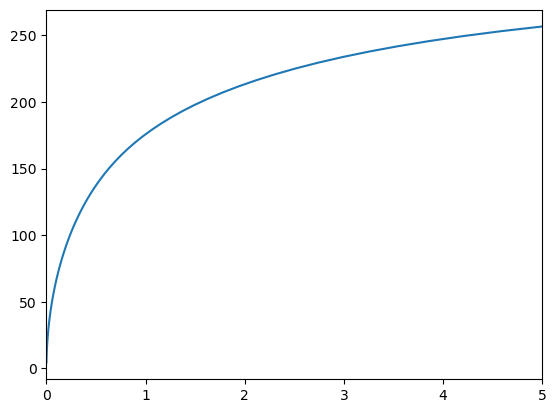

In [3]:
N = 100


arcmin = np.pi/(180.*60.)
delta_theta_arcmin = np.linspace(0,100,N)
delta_theta = delta_theta_arcmin*arcmin
zet_arr = np.geomspace(0.001,5,N)
covariance = np.zeros(N)
DM = np.zeros(N)
for j in range(N):
    c = get_cov(0.0, zet_arr[j], delta_theta[j])
    covariance[j] = c[0][0,0]
    DM[j] = c[1].DM[0]

plt.plot(zet_arr, (covariance)**.5)
plt.xlim(0,zet_arr[-1])

print(np.max(covariance**.5))


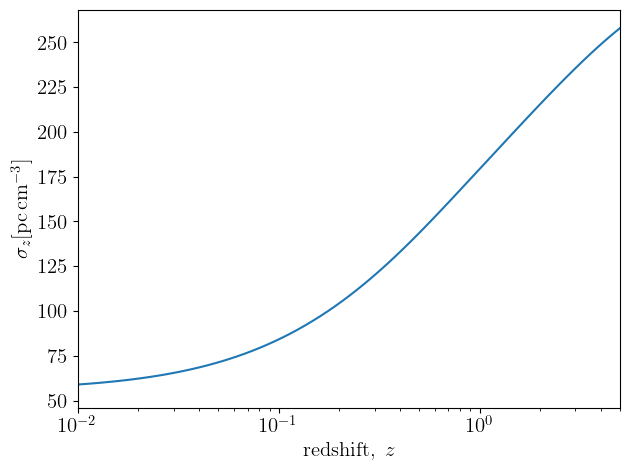

In [4]:
import matplotlib as mpl

fontsi = 15
fontsi2 = 15
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif')
mpl.rcParams['text.latex.preamble'] = r'\usepackage{{amsmath}}'
plt.tick_params(labelsize=fontsi)

sigma_host = 50
plt.semilogx(zet_arr, ((covariance) + sigma_host**2/(1+zet_arr)**2 + 25**2)**.5)

plt.xlabel(r"$\mathrm{redshift},\;z$", fontsize = fontsi)
plt.ylabel(r"$\sigma_z [\mathrm{pc\,cm}^{-3}]$", fontsize = fontsi)



np.savez("sigma_DM", sigma_DM = ((covariance))**.5, z = zet_arr, DM = DM)


np.savez("redshift_uncertainty", sigma_DM = ((covariance) + sigma_host**2/(1+zet_arr)**2 + 25**2)**.5, z = zet_arr, DM = DM)

plt.xlim(1e-2,zet_arr[-1])
plt.tight_layout()
plt.savefig("redshift_uncertainty.pdf")

[  70.79058802   70.86164361   70.9390882    71.02349677   71.11549612
   71.21576963   71.3250623    71.44418638   71.57402746   71.71555114
   71.86981025   72.03795286   72.22123089   72.4210096    72.63877792
   72.87615976   73.13492638   73.41700984   73.72451784   74.05974978
   74.42521454   74.8236497    75.2580428    75.7316545    76.24804396
   76.81109675   77.42505528   78.09455241   78.82464811   79.62086988
   80.48925711   81.43640975   82.46954203   83.59654136   84.82603336
   86.16745342   87.63112563   89.22834978   90.97149754   92.87411847
   94.9510574    97.21858401   99.69453631  102.39847936  105.35188098
  108.57830634  112.10363345  115.95629185  120.16752683  124.77169205
  129.80657315  135.31374553  141.33896945  147.93262571  155.15019505
  163.05278484  171.70770571  181.18910114  191.5786319   202.96621688
  215.45083024  229.14135399  244.1574826   260.6306781   278.70517988
  298.53905347  320.30526898  344.19280493  370.40773203  399.17421989
  430.

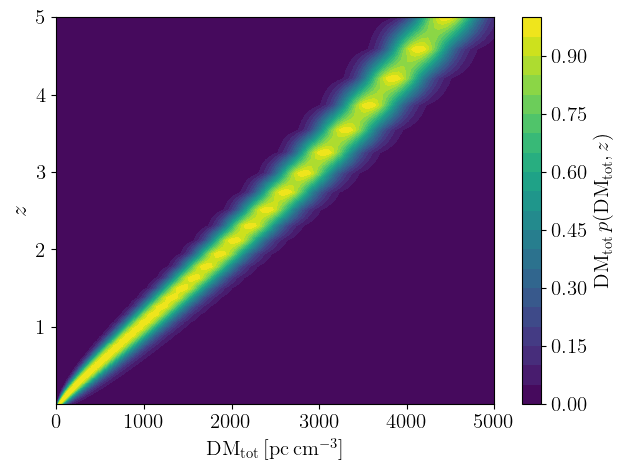

In [5]:
DM_mean = DM + 20 + 50/(1+zet_arr)
print(DM_mean)
sigma_lss = ((covariance) + sigma_host**2/(1+zet_arr)**2 + 25**2)
mu_ln = np.log(DM_mean**2/np.sqrt(DM_mean**2+sigma_lss))
sigma_ln = np.sqrt(np.log(1+sigma_lss/DM_mean**2))

def pdf_log_normal(x, mu, sigma, diag = False):
    if isinstance(mu, np.ndarray):
        if diag:
            if len(x.shape)> 1:
                result = np.zeros_like(x)
                for i in range(len(x[:,0])):
                    result[i,:] = 1./(x[i, :]*sigma[i]*np.sqrt(2*np.pi))*np.exp(-(np.log(x[i, :]) - mu[i])**2/2/sigma[i]**2)
                #x = np.expand_dims(x, axis=-1)
                #result = (np.diagonal(1./(x*np.sqrt(2*np.pi))*np.exp(-(np.log(x) - mu[None, : ])**2/2/sigma[None, :]**2)*sigma[None, :], axis1=-1,axis2=0)).T
            else:            
                result = 1./(x*sigma*np.sqrt(2*np.pi))*np.exp(-(np.log(x) - mu)**2/2/sigma**2)
        else:
            x = np.expand_dims(x, axis=-1)
            result = 1./(x*np.sqrt(2*np.pi))*np.exp(-(np.log(x) - mu[None, : ])**2/2/sigma[None, :]**2)*sigma[None, :]
    else:
        result = 1./(x*sigma*np.sqrt(2*np.pi))*np.exp(-(np.log(x) - mu)**2/2/sigma**2)
    return np.nan_to_num(result, nan=0.0)

X_DM = np.geomspace(1,1e4,1000)
pdf_ln = pdf_log_normal(X_DM, mu_ln, sigma_ln)*DM_mean

for i in range(len(zet_arr)):
    pdf_ln[:,i] /=np.max(pdf_ln[:,i])
print(pdf_ln.shape)
    

fontsi = 15
fontsi2 = 15
plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif')
mpl.rcParams['text.latex.preamble'] = r'\usepackage{{amsmath}}'
plt.tick_params(labelsize=fontsi)


contour = plt.contourf(X_DM, zet_arr, pdf_ln.T, levels=20, cmap='viridis')  # Filled contours
#plt.xscale("log")
#plt.yscale("log")
plt.xlabel(r"$\mathrm{DM}_\mathrm{tot}\,[\mathrm{pc\,cm}^{-3}]$", fontsize = fontsi)
plt.ylabel(r"$z$", fontsize = 17)
plt.xlim(0,5000)

cbar = plt.colorbar(contour)
cbar.ax.tick_params(labelsize=fontsi)  
cbar.set_label(r'$\mathrm{DM}_\mathrm{tot}\,p(\mathrm{DM}_\mathrm{tot},z) $', fontsize=fontsi2)  # Set font size for colorbar label

plt.tight_layout()
plt.savefig("pdf_redshift.pdf")

In [6]:
N = 10
covariance_no_ep_list = []
covariance_ep_list = []
arcmin = np.pi/(180.*60.)
delta_theta_arcmin = np.linspace(0,100,N)
delta_theta = delta_theta_arcmin*arcmin
zet_arr = np.linspace(0.1,2,N)
for j in range(N):
        print(j)
        covariance_no_ep = np.zeros(N)
        covariance_ep = np.zeros(N)
        for i in range(N):
                covariance_no_ep[i] = get_cov(0.0, zet_arr[j], delta_theta[i])[0][0,1]
                covariance_ep[i] = get_cov(5e-20, zet_arr[j], delta_theta[i])[0][0,1]
        covariance_no_ep_list.append(covariance_no_ep)
        covariance_ep_list.append(covariance_ep)



0
1
2
3
4
5
6
7
8
9


In [7]:
covariance_no_ep_list = np.array(covariance_no_ep_list)

print(covariance_no_ep_list.shape)

np.savez("for_kritti", covariance = covariance_no_ep_list, redshift = zet_arr, theta = delta_theta)

(10, 10)


In [8]:
data = np.load("for_kritti.npz")
print(data.keys())

KeysView(NpzFile 'for_kritti.npz' with keys: covariance, redshift, theta)


/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_16959/2077749668.py:39: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(delta_theta_arcmin[0],delta_theta_arcmin[-1])


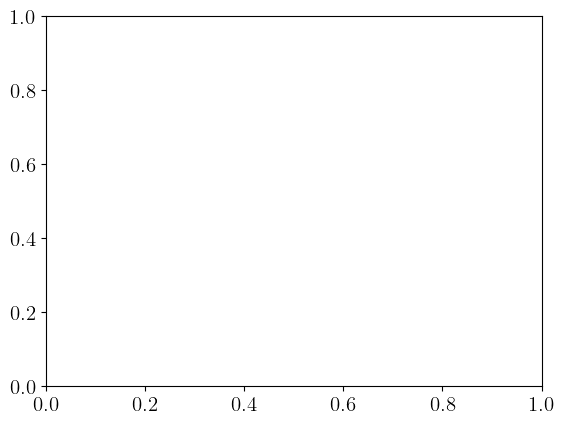

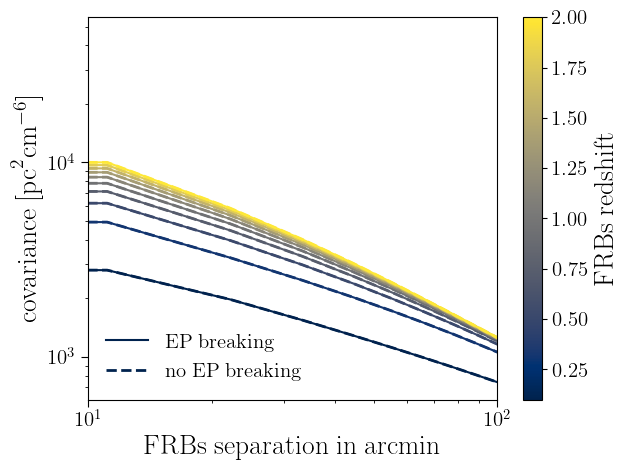

In [9]:
fontsi = 15
fontsi2 = 20

plt.tick_params(labelsize=fontsi)


plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif')
plt.rc('image', interpolation='none')


cmap = plt.get_cmap('cividis')
norm = plt.Normalize(vmin=zet_arr.min(), vmax=zet_arr.max())

# Plotting
fig, ax = plt.subplots()
# Add colorbar

i = 0
for param in zet_arr:
    if i == 0:
        plt.loglog(delta_theta_arcmin, covariance_ep_list[i], ls = "-",color=cmap(norm(param)), label=r"$\mathrm{EP\;breaking}$")
        plt.loglog(delta_theta_arcmin, covariance_no_ep_list[i], ls = "--",color=cmap(norm(param)), lw = 2, label=r"$\mathrm{no\;EP\;breaking}$")
    else:
        plt.loglog(delta_theta_arcmin, covariance_ep_list[i], ls = "-",color=cmap(norm(param)))
        plt.loglog(delta_theta_arcmin, covariance_no_ep_list[i], ls = "--",color=cmap(norm(param)), lw = 2)
    i+=1
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax)

ax.set_xlabel(r"$\mathrm{FRBs\;separation\;in\;\mathrm{arcmin}}$", fontsize = fontsi2)
ax.set_ylabel(r"$\mathrm{covariance\;[pc}^{2}\mathrm{cm}^{-6}]$", fontsize = fontsi2)

ax.tick_params(axis='both', which='major', labelsize=fontsi, length=5)  # Adjust as needed
cbar.ax.tick_params(labelsize=fontsi)  
cbar.set_label(r'$\mathrm{FRBs\;redshift}$', fontsize=fontsi2)  # Set font size for colorbar label

plt.legend(fontsize=fontsi, loc='lower left',frameon=False)
plt.xlim(delta_theta_arcmin[0],delta_theta_arcmin[-1])
plt.tight_layout()
plt.savefig("frb_ep_breaking_covariance.pdf")


In [10]:
Nz = 40
covariance_no_photon_mass = []
covariance_photon_mass = []
arcmin = np.pi/(180.*60.)
delta_theta_arcmin = np.geomspace(1,1000,Nz)
delta_theta = delta_theta_arcmin*arcmin
zet_arr = np.geomspace(0.01,3,Nz)
m_photon = np.linspace(1e-20,1e-22,N)
for i in range(N):
        for j in range(Nz):
                if i == 0:
                        covariance_no_photon_mass.append(get_cov(0.0, zet_arr[j], delta_theta[0]))
                covariance_photon_mass.append(get_cov(0.0, zet_arr[j], delta_theta[0],mass_photon=m_photon[i]))
        

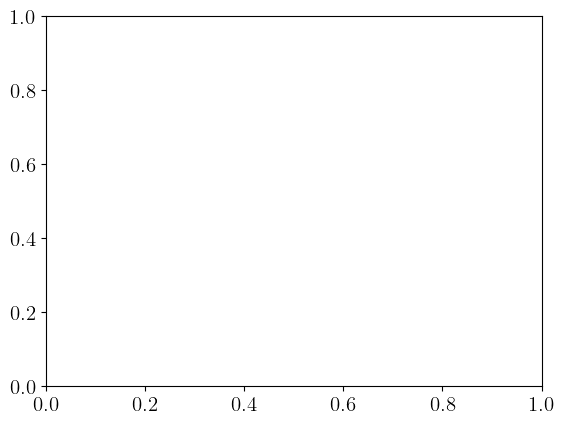

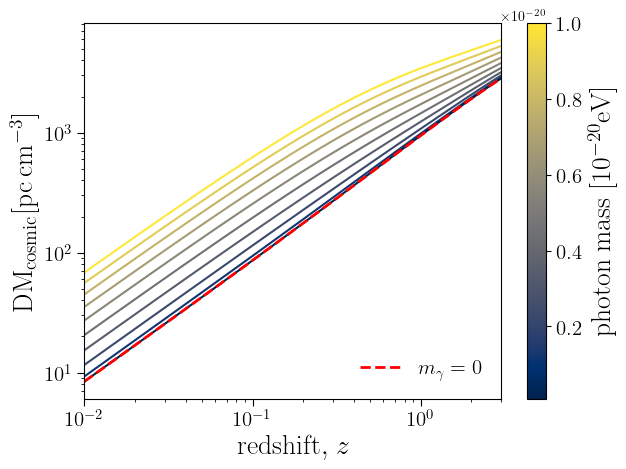

In [11]:
DM_no_photon_mass = np.zeros((N,Nz))
DM_photon_mass = np.zeros((N,Nz))
flat_idx=0
    


fontsi = 15
fontsi2 = 20

plt.tick_params(labelsize=fontsi)


plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif')
plt.rc('image', interpolation='none')

#m_photon/= 1e20
cmap = plt.get_cmap('cividis')
norm = plt.Normalize(vmin=m_photon.min(), vmax=m_photon.max())

# Plotting
fig, ax = plt.subplots()
# Add colorbar
flat_idx = 0
for i in range(N):
    for j in range(Nz):
        DM_photon_mass[i,j] = covariance_photon_mass[flat_idx][1].DM[0]
        DM_no_photon_mass[i,j] =  covariance_no_photon_mass[j][1].DM[0]
        flat_idx +=1

for i in range(N):
    plt.plot(zet_arr, DM_photon_mass[i,:], ls = "-",color=cmap(norm(m_photon[i])))

plt.semilogy(zet_arr, DM_no_photon_mass[i,:], ls = "--",color="red", lw = 2, label = r"$m_\gamma = 0$")
plt.xlim(zet_arr[0],zet_arr[-1])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax)

plt.loglog()


ax.set_xlabel(r"$\mathrm{redshift,\;}z$", fontsize = fontsi2)
ax.set_ylabel(r"$\mathrm{DM}_\mathrm{cosmic}[\mathrm{pc\,cm}^{-3}]$", fontsize = fontsi2)

ax.tick_params(axis='both', which='major', labelsize=fontsi, length=5)  # Adjust as needed
cbar.ax.tick_params(labelsize=fontsi)  
cbar.set_label(r'$\mathrm{photon\;mass\;[10^{-20}eV]}$', fontsize=fontsi2)  # Set font size for colorbar label

plt.legend(fontsize=fontsi, loc='lower right',frameon=False)
plt.tight_layout()
plt.savefig("frb_mphot_signal.pdf")

In [12]:
def sample_from_pdf(x, pdf, size=1, rng=None):
    """
    Sample from a 1D PDF given as arrays.

    Parameters
    ----------
    x : array-like, shape (M,)
        Support (sorted, increasing) for the PDF (values of the random variable).
    pdf : array-like, shape (M,)
        PDF values at points x (non-negative, can be unnormalized).
    size : int or tuple of ints, optional
        Number of samples to draw. Default 1.
    rng : np.random.Generator or None, optional
        Random number generator. If None, use np.random.default_rng().

    Returns
    -------
    samples : ndarray
        Samples drawn from the PDF, shape given by `size`.
    """
    x = np.asarray(x)
    pdf = np.asarray(pdf)
    if x.ndim != 1 or pdf.ndim != 1:
        raise ValueError("x and pdf must be one-dimensional arrays.")
    if x.size != pdf.size:
        raise ValueError("x and pdf must have the same length.")
    if np.any(pdf < 0):
        raise ValueError("pdf must be non-negative.")

    # Ensure x is strictly increasing
    if not np.all(np.diff(x) > 0):
        # If equal neighbors, slightly perturb or re-bin; here we require strictly increasing
        raise ValueError("x must be strictly increasing.")

    # Normalize pdf using trapezoidal rule
    area = np.trapz(pdf, x)
    if area <= 0:
        raise ValueError("PDF has zero integral; cannot sample.")
    pdf_norm = pdf / area

    # Build CDF using cumulative trapezoidal integration -> CDF in [0,1]
    # cdf[i] = integral from x[0] to x[i] of pdf_norm dx
    cdf = np.empty_like(pdf_norm)
    cdf[0] = 0.0
    # cumulative integral at each successive point
    cdf[1:] = np.cumsum(0.5 * (pdf_norm[:-1] + pdf_norm[1:]) * np.diff(x))
    # enforce exact 1 at last element to avoid numerical issues
    cdf /= cdf[-1]

    # Inverse transform sampling via interpolation
    if rng is None:
        rng = np.random.default_rng()
    u = rng.random(size=np.prod(size)).reshape(size) if np.shape(size) else rng.random(size)
    # Flatten u, interpolate, then reshape
    u_flat = np.ravel(u)
    samples_flat = np.interp(u_flat, cdf, x)  # returns x values where CDF equals u
    return samples_flat.reshape(u.shape)

In [13]:
def sample_southern_isotropic(n):
    # Sample cos(dec) uniformly over southern hemisphere: cos(dec) in [-1, 0)
    u = np.random.uniform(-1.0, 0.0, size=n)
    dec = np.degrees(np.arccos(u)) - 90.0  # convert to degrees: dec in (-90, 0]
    ra = np.random.uniform(0.0, 360.0, size=n)  # RA in degrees
    return ra, dec

# Example:
n_with_host = 50
ra, dec = sample_southern_isotropic(n_with_host)

p_of_z = np.load("./ska_predictions/Band2_AAstar_sys_pz.npy")
N_of_z = np.load("./ska_predictions/Band2_AAstar_sys_N.npy")

z_vals = np.load("./ska_predictions/zvals.npy")


index = np.argmax(N_of_z)
index = np.argmin(N_of_z)
factor = (N_of_z[index]/n_with_host)

norm = np.trapz(p_of_z[index,:], x = z_vals)
p_of_z[index,:] /= norm
zet = sample_from_pdf(z_vals,p_of_z[index,:],size = n_with_host)
#Compute pairwise distance on the sky between FRBs

delta_theta = np.zeros((n_with_host, n_with_host))
for i in range(n_with_host):
    for j in range(n_with_host):
        if (i != j):
            delta_theta[i, j] = np.arccos(np.sin(
                ra[i])*np.sin(ra[j]) + np.cos(ra[i])*np.cos(ra[j])*np.cos(dec[i] - dec[j]))
            

def get_cov_ep(delta_gamma, zet, delta_theta, mass_photon =0.0, diagonal = False, non_verbose = True):
    sigma8 = 0.834  # fluctuation amplitude
    h = 0.674       # Hubble constant
    omegam = 0.3    # matter density parameter
    omegab = 0.05   # baryon density parameter
    omegade = 1.0 - omegam # DE density parameter
    w0 = -1         # DE equation of state
    wa = 0          # DE equation of state
    ns = 0.963      # spectral index of primordial power spectrum
    neff = 3.046    # effective number of relativistic degrees of freedom
    mnu = 0         # Neutrino mass in eV
    Tcmb0 = 2.725   
    alpha_B = 0.1   # Horndeski braiding
    alpha_M = 0.1   # Horndeski Planck mass running
    log_TAGN = 7.8  # feedback parameter (Mead2020)
    ks = 0.1        # screening scale for modified gravity
    keys = ['sigma_8', 'h', 'omega_m', 'omega_b', 'omega_de', 'w0', 'wa',
            'ns', 'neff', 'm_nu', 'Tcmb0', 'alpha_B', 'alpha_M', 'logTAGN', 'ks', 'delta_gamma', 'mass_photon', 'diagonal']
    values = [sigma8, h, omegam, omegab, omegade,
            w0, wa,  ns, neff, mnu, Tcmb0, alpha_B, alpha_M, log_TAGN, ks, delta_gamma, mass_photon, diagonal]
    cosmo = dict(zip(keys, values))
    cov = frb.covariance_frb_background(cosmo,bias_emu,power_emu,zet,delta_theta,flat_sky=True,
                                        frequency_band=.8*np.ones_like(zet), frequency_width=0.8*np.ones_like(zet), non_verbose = non_verbose)
    return cov.covariance, cov

eps = 1e-2
fid = 1e-13
cov_plus = get_cov_ep(fid*(1+eps), zet, delta_theta, mass_photon =0.0, diagonal = False, non_verbose = False)
cov_minus = get_cov_ep(fid*(1-eps), zet, delta_theta, mass_photon =0.0, diagonal = False, non_verbose = False)
cov = get_cov_ep(0, zet, delta_theta, mass_photon =0.0, diagonal = False, non_verbose = False)




dgamma = fid*(1+eps) - fid*(1-eps) 
dcov = (cov_plus[0] - cov_minus[0])/dgamma
sigma_host = 100**2/(1+zet) + 50**2
sigma2 = 0.5*np.trace(dcov@np.linalg.inv(cov[0] +np.diag(sigma_host))@dcov@np.linalg.inv(cov[0] +np.diag(sigma_host)))*factor
print(np.sqrt(1/sigma2))

/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_16959/1924579414.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(p_of_z[index,:], x = z_vals)
/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_16959/2021850385.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pdf, x)
100%|██████████| 50/50 [00:38<00:00,  1.31it/s]


2.579918587455429e-13


# Photon mass

In [14]:
def sample_southern_isotropic(n):
    # Sample cos(dec) uniformly over southern hemisphere: cos(dec) in [-1, 0)
    u = np.random.uniform(-1.0, 0.0, size=n)
    dec = np.degrees(np.arccos(u)) - 90.0  # convert to degrees: dec in (-90, 0]
    ra = np.random.uniform(0.0, 360.0, size=n)  # RA in degrees
    return ra, dec

# Example:
n_with_host = 50
ra, dec = sample_southern_isotropic(n_with_host)

p_of_z = np.load("./ska_predictions/Band2_AA4_sys_pz.npy")
N_of_z = np.load("./ska_predictions/Band2_AA4_sys_N.npy")

z_vals = np.load("./ska_predictions/zvals.npy")


index = np.argmax(N_of_z)
#index = np.argmin(N_of_z)
factor = (N_of_z[index]/n_with_host)

norm = np.trapz(p_of_z[index,:], x = z_vals)
p_of_z[index,:] /= norm
zet = sample_from_pdf(z_vals,p_of_z[index,:],size = n_with_host)
print(np.min(zet))
#Compute pairwise distance on the sky between FRBs

delta_theta = np.zeros((n_with_host, n_with_host))
for i in range(n_with_host):
    for j in range(n_with_host):
        if (i != j):
            delta_theta[i, j] = np.arccos(np.sin(
                ra[i])*np.sin(ra[j]) + np.cos(ra[i])*np.cos(ra[j])*np.cos(dec[i] - dec[j]))
            

def get_cov_ep(delta_gamma, zet, delta_theta, mass_photon =0.0, diagonal = False, non_verbose = True, bg_only=False, TAGN = 7.8):
    sigma8 = 0.834  # fluctuation amplitude
    h = 0.674       # Hubble constant
    omegam = 0.3    # matter density parameter
    omegab = 0.05   # baryon density parameter
    omegade = 1.0 - omegam # DE density parameter
    w0 = -1         # DE equation of state
    wa = 0          # DE equation of state
    ns = 0.963      # spectral index of primordial power spectrum
    neff = 3.046    # effective number of relativistic degrees of freedom
    mnu = 0         # Neutrino mass in eV
    Tcmb0 = 2.725   
    alpha_B = 0.1   # Horndeski braiding
    alpha_M = 0.1   # Horndeski Planck mass running
    log_TAGN = TAGN  # feedback parameter (Mead2020)
    ks = 0.1        # screening scale for modified gravity
    keys = ['sigma_8', 'h', 'omega_m', 'omega_b', 'omega_de', 'w0', 'wa',
            'ns', 'neff', 'm_nu', 'Tcmb0', 'alpha_B', 'alpha_M', 'logTAGN', 'ks', 'delta_gamma', 'mass_photon', 'diagonal']
    values = [sigma8, h, omegam, omegab, omegade,
            w0, wa,  ns, neff, mnu, Tcmb0, alpha_B, alpha_M, log_TAGN, ks, delta_gamma, mass_photon, diagonal]
    cosmo = dict(zip(keys, values))
    cov = frb.covariance_frb_background(cosmo,bias_emu,power_emu,zet,delta_theta,flat_sky=True,
                                        frequency_band=.8*np.ones_like(zet), frequency_width=0.8*np.ones_like(zet), non_verbose = non_verbose,
                                        bg_only=bg_only)
    if bg_only:
        return cov
    else:
        return cov.covariance, cov

eps = 1e-2
fid = 1e-20
cov = get_cov_ep(0, zet, delta_theta, mass_photon =fid, diagonal = False, non_verbose = False)
cov_plus = get_cov_ep(0, zet, delta_theta, mass_photon =fid*(1+eps), diagonal = False, non_verbose = False, bg_only=True)
cov_minus = get_cov_ep(0., zet, delta_theta, mass_photon =fid*(1-eps), diagonal = False, non_verbose = False, bg_only=True)




dgamma = fid*(1+eps) - fid*(1-eps) 
dmu = (cov_plus.DM - cov_minus.DM)/dgamma
dmu_outer = np.outer(dmu,dmu)
sigma_host = 100**2/(1+zet) + 50**2
icov = np.linalg.inv(cov[0] +np.diag(sigma_host))
sigma2 = 0.5*np.trace(icov@dmu_outer)*factor
print(np.sqrt(1/sigma2)/np.sqrt(5))

/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_16959/611175947.py:22: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(p_of_z[index,:], x = z_vals)
/var/folders/4k/46233y0d3tx9bcbm7l78j0mr0000gn/T/ipykernel_16959/2021850385.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pdf, x)


0.14171527282130517


 16%|█▌        | 8/50 [00:12<01:05,  1.55s/it]


KeyboardInterrupt: 

In [ ]:
cov = get_cov_ep(0, zet, delta_theta, diagonal = False, non_verbose = False)




100%|██████████| 50/50 [00:45<00:00,  1.10it/s]


AttributeError: 'tuple' object has no attribute 'ell'

1024
2048
4096
8192


Text(0, 0.5, '$\\sigma_\\mathrm{full}/\\sigma_\\mathrm{map}$')

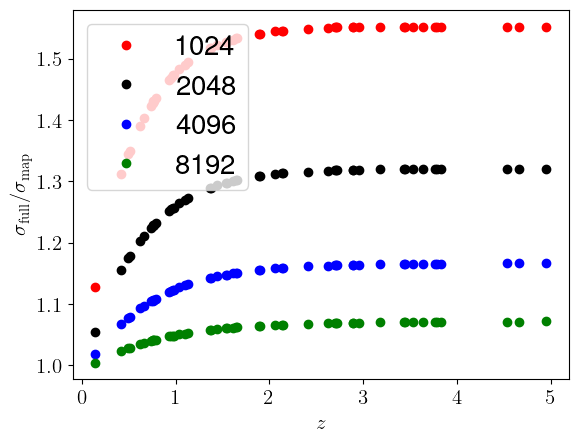

In [21]:
#plt.loglog(cov[-1].ell,cov[-1].C_ell[:,-1,-1])
import healpy as hp
import scipy.integrate as sci_int

fontsi = 15
fontsi2 = 20

plt.tick_params(labelsize=fontsi)


plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif')
plt.rc('image', interpolation='none')


color = ['red', 'black', 'blue', 'green']

NNside = 14
min = 10
sigma = []
for index_nside in range(min,NNside):
    nside = 2**index_nside  # Example resolution
    print(nside)
    lmax = 3 * nside - 1  # Choose an appropriate lmax
    ell = np.arange(lmax + 1) # Array of multipoles
    window = hp.pixwin(nside=nside, lmax=lmax)
    for index_z in range(len(cov[-1].zet)):
        C_ell_interp = np.interp(ell,cov[-1].ell,cov[-1].C_ell[:,index_z, index_z])
        #plt.semilogx(ell, C_ell_interp*ell, ls = "--")
        if index_nside == min:
            sigma.append(sci_int.simpson(cov[-1].C_ell[:,index_z, index_z]*cov[-1].ell, x = cov[-1].ell))

        sigma_hp = sci_int.simpson((C_ell_interp*ell*window**2)[1:], x = ell[1:])

        if index_z == 0:
            plt.plot(cov[-1].zet[index_z],(sigma[index_z]/sigma_hp)**.5, ls = "", marker = "o", label = str(nside), color = color[index_nside-min])
        else:
            plt.plot(cov[-1].zet[index_z],(sigma[index_z]/sigma_hp)**.5, ls = "", marker = "o",  color = color[index_nside-min])


plt.legend(fontsize = fontsi2, loc = "upper left")
plt.xlabel(r"$z$",fontsize = fontsi)
plt.ylabel(r"$\sigma_\mathrm{full}/\sigma_\mathrm{map}$",fontsize = fontsi)


In [24]:
import math

class LogNormalDistribution:
    def __init__(self, mean, variance):
        # Calculate mu and sigma from mean and variance
        self.sigma_squared = np.log(1 + variance / mean**2)
        self.sigma = np.sqrt(self.sigma_squared)
        self.mu = np.log(mean) - self.sigma_squared / 2
    
    def pdf(self, x):
        # Compute the probability density function at x
        coeff = 1 / (x * self.sigma * np.sqrt(2 * np.pi))
        exponent = -((np.log(x) - self.mu) ** 2) / (2 * self.sigma_squared)
        return coeff * np.exp(exponent)
    
    def cdf(self, x):
        # Optional: compute the cumulative distribution function
        if x <= 0:
            return 0
        z = (np.log(x) - self.mu) / self.sigma
        return 0.5 + 0.5 * np.erf(z / np.sqrt(2))

0.3774032681610915


In [16]:

cov = get_cov_ep(0, zet, delta_theta, mass_photon =0, diagonal = False, non_verbose = False, TAGN = 7.3)
cov_fb = get_cov_ep(0, zet, delta_theta, mass_photon =0, diagonal = False, non_verbose = False, TAGN= 8.3)


100%|██████████| 50/50 [00:35<00:00,  1.40it/s]


In [22]:
sigma = []
sigma_fb = []
for index_z in range(len(cov[-1].zet)):
    C_ell_interp = np.interp(ell,cov[-1].ell,cov[-1].C_ell[:,index_z, index_z])
    sigma.append(sci_int.simpson(cov[-1].C_ell[:,index_z, index_z]*cov[-1].ell, x = cov[-1].ell))
    C_ell_interp = np.interp(ell,cov_fb[-1].ell,cov[-1].C_ell[:,index_z, index_z])
    sigma_fb.append(sci_int.simpson(cov_fb[-1].C_ell[:,index_z, index_z]*cov_fb[-1].ell, x = cov_fb[-1].ell))



In [28]:
from scipy.interpolate import UnivariateSpline


fontsi = 20
fontsi2 = 20
plt.rc('text', usetex=True)
plt.rc('font', family='Arial')
plt.rc('image', interpolation='none')
#plt.rcParams['font.family'] = 'sans-serif'
#plt.rcParams['font.sans-serif'] = 'Helvetica'


x = np.geomspace(1e-1,1e4,1000)
x_MW = np.geomspace(1e-1,1e4,1000)
# Example usage:

redshifts = np.linspace(0.1,2,100)#0.5 + 0.005*np.arange(600)
sorted_indices = np.argsort(cov[-1].zet)

mean = UnivariateSpline(cov[-1].zet[sorted_indices], cov[-1].DM[sorted_indices], s=0, k= 1)(redshifts)
variance = UnivariateSpline(cov[-1].zet[sorted_indices], np.array(sigma)[sorted_indices], s=0, k= 1)(redshifts)
variance_fb = UnivariateSpline(cov[-1].zet[sorted_indices],  np.array(sigma_fb)[sorted_indices], s=0, k= 1)(redshifts)

x = np.geomspace(1e-1,1e4,1000)
x_MW = np.geomspace(1e-1,1e4,1000)

lognorm_lss = []
lognorm_host = []
lognorm_host_fb = []

lognorm_lss_fb = []
MW = 1./np.sqrt(2*np.pi*20**2)*np.exp(-0.5*(x_MW - 50)**2/20**2)

for i in range(len(redshifts)):
    lognorm_lss.append(LogNormalDistribution(mean[i], variance[i]))
    lognorm_lss_fb.append(LogNormalDistribution(mean[i], variance_fb[i]))

    lognorm_host.append(LogNormalDistribution(150/(1+redshifts[i]), 150**2/(1+redshifts[i])**2))
    lognorm_host_fb.append(LogNormalDistribution(90/(1+redshifts[i]), 100**2/(1+redshifts[i])**2))




<Figure size 640x480 with 0 Axes>

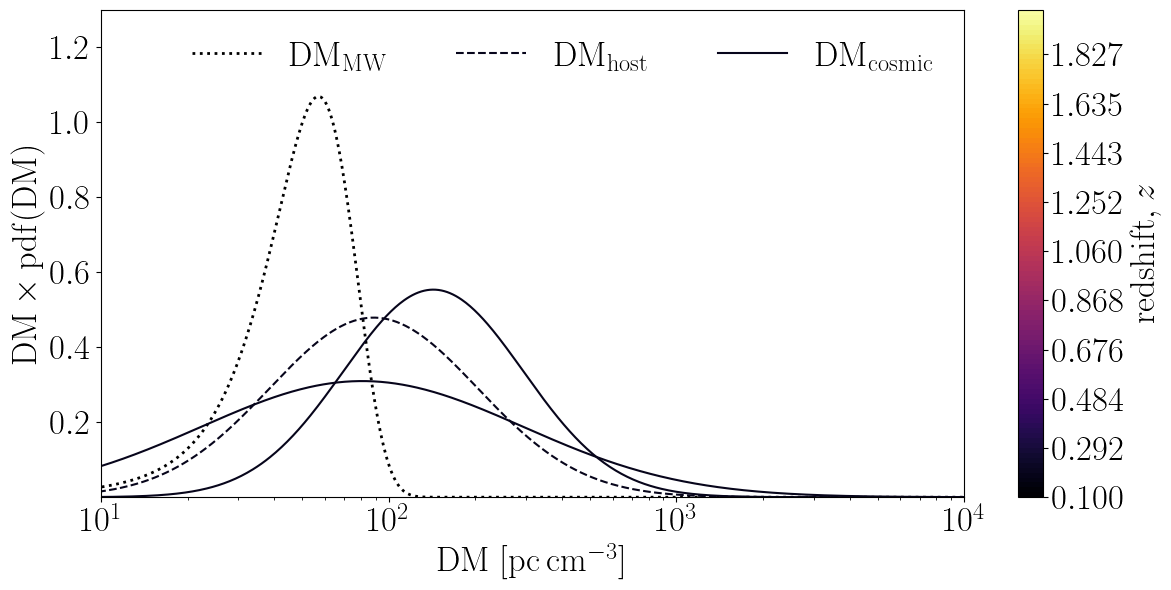

In [29]:
from matplotlib.pyplot import cm
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker

N = len(redshifts)
fig = plt.figure()
ax = fig.add_subplot()
nl = int(N)
color_idx = np.linspace(0, 1, nl)
cmap_name = 'inferno'
data = np.linspace(1e4, 1e5, 100).reshape(10, 10)
cmap = plt.get_cmap(cmap_name)
rgb_array = np.array(cmap(np.arange(0,cmap.N)) )
parula_map = LinearSegmentedColormap.from_list(
    'cool', rgb_array)

cmap_name = 'inferno'
cmap = plt.get_cmap(cmap_name)
rgb_array = np.array(cmap(np.arange(0,cmap.N)) )
parula_map_2 = LinearSegmentedColormap.from_list(
    'cool', rgb_array)

plt.clf()

fontsi = 20
fontsi2 = 20
fig = plt.figure(figsize=(12,6) )
ax = fig.add_subplot()
plt.tick_params(labelsize=fontsi)
fontsi = 25
fontsi2 = 25
lmin = 1
levels_chi = []
Z = [[0, 0], [0, 0]]
#lmax = nl 
#for i in range(nl):
#    levels_chi.append((((lmin) + i*((lmax)-(lmin))/(nl-1.0))))
CS3 = ax.contourf(Z, redshifts, cmap=parula_map)

cm = fig.colorbar(CS3)
cm.set_label(r'$\mathrm{redshift,\;}z$', fontsize=fontsi)
plt.rcParams['text.latex.preamble'] = r'\usepackage{helvet}\renewcommand{\familydefault}{\sfdefault}'

plt.tick_params(labelsize=fontsi)

plt.plot(x, x*MW, ls = ":", color = "black", label = r"$\mathrm{DM}_\mathrm{MW}$", lw = 2)

i = 5
plt.plot(x+20000, x*lognorm_host[i].pdf(x), ls = "--", label = r"$\mathrm{DM}_\mathrm{host}$", color = parula_map(color_idx[i]))
plt.plot(x+20000, x*lognorm_lss[i].pdf(x), ls = "-", label = r"$\mathrm{DM}_\mathrm{cosmic}$", color = parula_map(color_idx[i]))
plt.plot(x, x*lognorm_lss[i].pdf(x), ls = "-", color = parula_map(color_idx[i]), alpha = 1)
plt.plot(x, x*lognorm_lss_fb[i].pdf(x), ls = "-", color = parula_map_2(color_idx[i]), alpha = 1)
plt.plot(x, x*lognorm_host[i].pdf(x), ls = "--", color = parula_map(color_idx[i]))

plt.xscale("log")
#plt.yscale("log")
plt.xlim(10,1e4)
cm.ax.tick_params(labelsize=fontsi)

# Define latex preamble to use Helvetica font

plt.legend(fontsize=fontsi,frameon = False, ncol = 3)
plt.tight_layout()
plt.xlabel(r"$\mathrm{DM\;}[\mathrm{pc}\,\mathrm{cm}^{-3}]$", fontsize=fontsi)
plt.ylabel(r"$\mathrm{DM}\times\mathrm{pdf}(\mathrm{DM})$", fontsize=fontsi)

plt.ylim(1e-5,1.3)
plt.tight_layout()
plt.savefig("heisenberg_likelihood.pdf")

<Figure size 640x480 with 0 Axes>

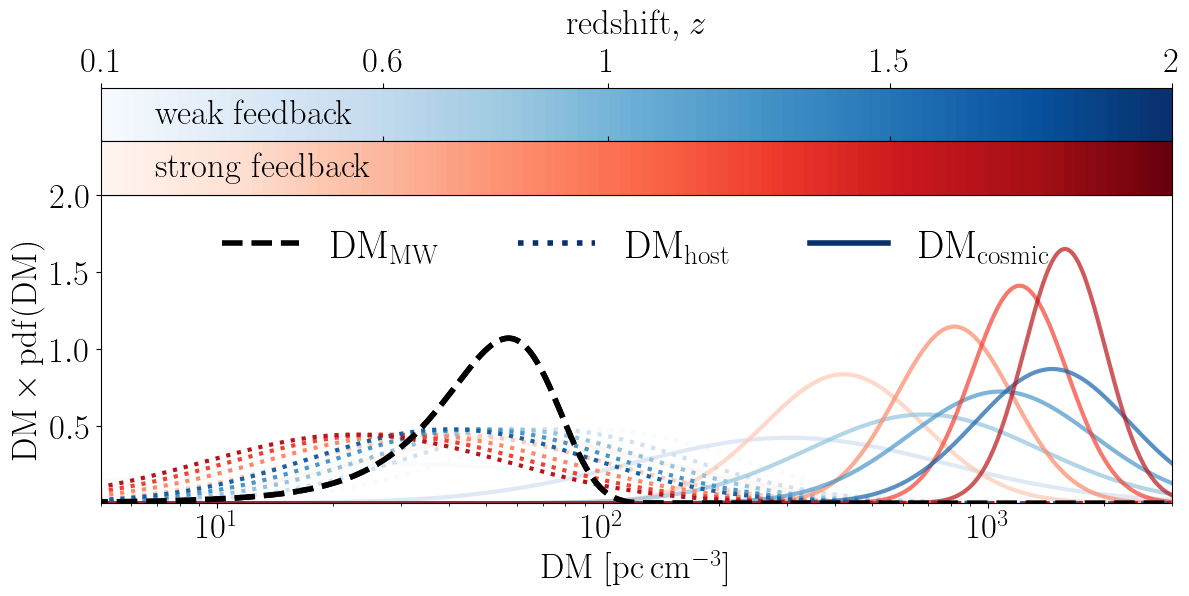

In [43]:
from matplotlib.pyplot import cm
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as ticker

N = len(redshifts)
fig = plt.figure()
ax = fig.add_subplot()
nl = int(N)
color_idx = np.linspace(0, 1, nl)
cmap_name = 'Blues'
data = np.linspace(1e4, 1e5, 100).reshape(10, 10)
cmap = plt.get_cmap(cmap_name)
rgb_array = np.array(cmap(np.arange(0,cmap.N)) )
parula_map = LinearSegmentedColormap.from_list(
    'cool', rgb_array)
cmap_name = 'Reds'
cmap = plt.get_cmap(cmap_name)
rgb_array = np.array(cmap(np.arange(0,cmap.N)) )
parula_map_2 = LinearSegmentedColormap.from_list(
    'cool', rgb_array)

plt.clf()

fontsi = 20
fontsi2 = 20
fig = plt.figure(figsize=(12,6) )
ax = fig.add_subplot()
plt.tick_params(labelsize=fontsi)
fontsi = 25
fontsi2 = 25
lmin = 1
levels_chi = []
Z = [[0, 0], [0, 0]]
#lmax = nl 
#for i in range(nl):
#    levels_chi.append((((lmin) + i*((lmax)-(lmin))/(nl-1.0))))
CS3 = ax.contourf(Z, redshifts, cmap=parula_map)

cm = fig.colorbar(CS3, location = "top", fraction=0.2, pad=-0.052)
cm.set_label(r'$\mathrm{redshift,\;}z$', fontsize=fontsi,labelpad = 10)
tick_vals = np.round(np.linspace(redshifts.min(), redshifts.max(), 5), 1)
tick_labels = [f"{v:.1f}".rstrip("0").rstrip(".") for v in tick_vals]
cm.set_ticks(tick_vals)
cm.set_ticklabels(tick_labels)

CS3 = ax.contourf(Z, redshifts, cmap=parula_map_2)

cm2 = fig.colorbar(CS3, location = "top",fraction=0.2, pad=0)
cm2.set_ticks(tick_vals)
cm2.set_ticklabels([])

cm.ax.text(0.05, 0.5, r'$\mathrm{weak\;feedback}$', color='black', va='center', ha='left', transform=cm.ax.transAxes, fontsize = fontsi)
cm2.ax.text(0.05, 0.5, r'$\mathrm{strong\;feedback}$', color='black', va='center', ha='left', transform=cm2.ax.transAxes, fontsize = fontsi)

# Position colorbars manually to stack with no space
# Get the axes of the colorbars
#cm.ax.set_position([1.05, 0.55, 0.02, 0.4])  # [left, bottom, width, height]
#cm2.ax.set_position([1.05, 0.15, 0.02, 0.4])


#cbar = fig.colorbar(im, ax=ax, location='right', pad=0.1)


plt.rcParams['text.latex.preamble'] = r'\usepackage{helvet}\renewcommand{\familydefault}{\sfdefault}'

plt.tick_params(labelsize=fontsi)

plt.plot(x, x*MW, ls = "--", color = "black", label = r"$\mathrm{DM}_\mathrm{MW}$", lw = 4)
plt.plot(x+20000, x*lognorm_host[i].pdf(x), ls = ":", label = r"$\mathrm{DM}_\mathrm{host}$", color = parula_map(color_idx[-1]), lw = 4)
plt.plot(x+20000, x*lognorm_lss[i].pdf(x), ls = "-", label = r"$\mathrm{DM}_\mathrm{cosmic}$", color = parula_map(color_idx[-1]), lw = 4)
for i in range(0,len(redshifts),20):
        
    plt.plot(x, x*lognorm_lss[i].pdf(x), ls = "-", color = parula_map(color_idx[i]), alpha = .7, lw = 3)
    plt.plot(x, x*lognorm_host[i].pdf(x), ls = ":", color = parula_map(color_idx[i]), lw = 3)
    plt.plot(x, x*lognorm_lss_fb[i].pdf(x), ls = "-", color = parula_map_2(color_idx[i]), alpha = .7, lw = 3)
    plt.plot(x, x*lognorm_host_fb[i].pdf(x), ls = ":", color = parula_map_2(color_idx[i]), lw = 3)

plt.plot(x, x*MW, ls = "--", color = "black", lw = 4)

plt.xscale("log")
#plt.yscale("log")
plt.xlim(5,3e3)
cm.ax.tick_params(labelsize=fontsi)
cm2.ax.tick_params(labelsize=fontsi)

# Define latex preamble to use Helvetica font

plt.legend(fontsize=28,frameon = False, ncol = 3, loc = 'upper center')
plt.tight_layout()
plt.xlabel(r"$\mathrm{DM\;}[\mathrm{pc}\,\mathrm{cm}^{-3}]$", fontsize=fontsi)
plt.ylabel(r"$\mathrm{DM}\times\mathrm{pdf}(\mathrm{DM})$", fontsize=fontsi)

plt.ylim(1e-5,2)
plt.tight_layout()
plt.savefig("heisenberg_likelihood.pdf")